# Affiliate Marketing ETL & Analytics Pipeline

## Overview
Built an ETL pipeline to process affiliate marketing clickstream and conversion data, generate KPIs, and analyze campaign performance.

## Dataset
- Clicks (~10K records)
- Conversions (~3K records)

## Tech Stack
Python (Pandas), Data Cleaning, ETL, Analytics, Matplotlib

## Pipeline Steps
1. Data Cleaning & Validation
2. Data Integration
3. Feature Engineering
4. KPI Computation
5. Aggregation & Analysis
## 6. Visualization

**## 1. Data Loading**

In [1]:
import pandas as pd

In [2]:
clicks=pd.read_csv("/data/clicks_data.csv")
conversions=pd.read_csv("/data/conversions_data.csv")

## 2. Data Quality Checks
- Missing values
- Data types
- Duplicate records

In [3]:
clicks.isnull().sum()

,0
click_id,0
timestamp,0
user_id,0
campaign_id,0
publisher_id,0
device,0
geo,0


In [4]:
conversions.isnull().sum()

,0
conversion_id,0
click_id,0
timestamp,0
revenue,0
status,0
campaign_id,0


In [5]:
clicks.dtypes

,0
click_id,int64
timestamp,object
user_id,int64
campaign_id,int64
publisher_id,int64
device,object
geo,object


In [6]:
conversions.dtypes

,0
conversion_id,int64
click_id,int64
timestamp,object
revenue,float64
status,object
campaign_id,int64


**2.Data Cleaning**

In [7]:
clicks.duplicated().sum()


np.int64(0)

In [8]:
conversions.duplicated().sum()

np.int64(0)

#####To identify duplicated data here in primary key

In [9]:
clicks.duplicated(subset=['click_id']).sum()

np.int64(0)

In [10]:
conversions.duplicated(subset=['conversion_id']).sum()

np.int64(0)

In [11]:
clicks['device'].unique()

array(['ios', 'android', 'desktop'], dtype=object)

In [12]:
clicks['geo'].unique()

array(['IN', 'UK', 'US', 'CA', 'AU'], dtype=object)

In [13]:
conversions['status'].value_counts()

,count
status,
approved,2545
rejected,455


## 3. Data Cleaning & Preprocessing
- Timestamp conversion
- Handling missing values
- Filtering invalid records

In [77]:
# Convert timestamp columns to datetime
clicks['timestamp'] = pd.to_datetime(clicks['timestamp'], errors='coerce')


In [75]:
conversions['timestamp'] = pd.to_datetime(conversions['timestamp'], errors='coerce')


In [16]:
clicks['timestamp'].isna().sum()

np.int64(0)

In [17]:
conversions['timestamp'].isna().sum()

np.int64(0)

In [18]:
clicks.dropna(subset=['timestamp'], inplace=True)
conversions.dropna(subset=['timestamp'], inplace=True)


In [19]:
conversions['revenue'].isna().sum()

np.int64(0)

In [20]:
conversions['revenue'].isna().any()

np.False_

In [21]:
clicks['device'].isna().sum()

np.int64(0)

In [22]:
clicks['geo'].isna().sum()

np.int64(0)

In [23]:
conversions=conversions[conversions['revenue'] >= 0]

In [24]:
conversions=conversions[conversions['status'].isin(['approved','rejected'])]


## 4. Data Integration
Joining clicks and conversions data on click_id

In [25]:
df = clicks.merge(conversions, on='click_id', how='left')

In [26]:
df = df.rename(columns={
    'timestamp_x': 'click_timestamp',
    'timestamp_y': 'conversion_timestamp'
})


In [27]:
df=df.drop(columns=["campaign_id_y"])

In [28]:
df = df.rename(columns={'campaign_id_x': 'campaign_id'})


## 5. Feature Engineering
- Conversion flag
- Approval flag
- Conversion lag calculation

In [30]:
df['is_conversion']=df['conversion_id'].notnull().astype(int)

In [32]:
df['is_approved']=(df['status']=='approved').astype(int)


In [33]:
df['conversion_lag_minutes_raw'] = (
    (df['conversion_timestamp'] - df['click_timestamp']).dt.total_seconds() / 60
).round(2)

In [34]:
df['conversion_lag_minutes'] = df['conversion_lag_minutes_raw'].copy()
df.loc[df['conversion_lag_minutes'] < 0, 'conversion_lag_minutes'] = pd.NA

In [36]:
(df['conversion_lag_minutes'] < 0).sum()

np.int64(0)

In [37]:
df['conversion_lag_minutes'] = df['conversion_lag_minutes_raw'].copy()

# Handle invalid negative values
df.loc[df['conversion_lag_minutes'] < 0, 'conversion_lag_minutes'] = pd.NA

In [38]:
df

,click_id,click_timestamp,user_id,campaign_id,publisher_id,device,geo,conversion_id,conversion_timestamp,revenue,status,is_conversion,is_approved,conversion_lag_minutes_raw,conversion_lag_minutes
0,1,2026-02-12 14:09:16.035014,3513,41,1,ios,IN,NaN,NaT,NaN,NaN,0,0,NaN,NaN
1,2,2026-02-22 23:04:16.035039,3765,27,3,android,UK,2234.0,2026-01-25 18:42:16.094357,14.77,approved,1,1,-40582.0,NaN
2,3,2026-01-01 05:04:16.035042,1798,1,12,android,US,1818.0,2026-01-27 11:33:16.093709,32.14,approved,1,1,37829.0,37829.0
3,4,2026-01-16 10:38:16.035045,1474,17,7,ios,US,1985.0,2026-02-03 12:01:16.093973,1.95,approved,1,1,26003.0,26003.0
4,5,2026-02-19 04:59:16.035047,3448,48,5,android,UK,NaN,NaT,NaN,NaN,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,2026-01-24 02:08:16.057584,4714,1,4,ios,US,NaN,NaT,NaN,NaN,0,0,NaN,NaN
9996,9997,2025-12-19 21:37:16.057585,4580,15,1,desktop,CA,NaN,NaT,NaN,NaN,0,0,NaN,NaN
9997,9998,2026-01-03 09:40:16.057587,2805,47,5,desktop,UK,NaN,NaT,NaN,NaN,0,0,NaN,NaN
9998,9999,2026-01-19 16:17:16.057588,2968,27,11,android,US,NaN,NaT,NaN,NaN,0,0,NaN,NaN


Computes the average conversion lag for each campaign using group By

In [39]:
avg_lag_campaign = df.groupby('campaign_id')['conversion_lag_minutes'].mean()
avg_lag_campaign


,conversion_lag_minutes
campaign_id,
1,33971.177778
2,32125.258065
3,28246.750000
4,28162.800000
5,30741.352941
6,34122.227273
7,30969.028571
8,36641.793103
9,33004.783784


## 6. Aggregations & KPI Calculation
- Campaign metrics
- Publisher metrics
- Revenue analysis

In [40]:
campaign_metrics=df.groupby('campaign_id').agg(
    total_clicks=('click_id','count'),
    total_conversions=('is_conversion','sum'),
    approved_conversions=('is_approved','sum'),
    total_revenue_per_campaign=('revenue','sum')
).reset_index()

In [42]:
campaign_metrics

,campaign_id,total_clicks,total_conversions,approved_conversions,total_revenue_per_campaign
0,1,209,69,58,1787.52
1,2,208,65,56,1632.95
2,3,211,58,45,1476.01
3,4,196,51,47,1156.35
4,5,208,66,59,1606.59
5,6,201,56,51,1521.80
6,7,210,68,60,1763.60
7,8,202,60,52,1532.30
8,9,210,71,58,1792.23
9,10,242,65,57,1531.80


**Publisher** **Metrics**

In [43]:
publisher_metrics=df.groupby('publisher_id').agg(
    avg_revenue=('revenue','mean')
).reset_index()

In [44]:
publisher_metrics

,publisher_id,avg_revenue
0,1,26.740256
1,2,26.887887
2,3,24.755062
3,4,26.323836
4,5,24.551377
5,6,26.184932
6,7,27.114898
7,8,25.269157
8,9,26.894431
9,10,25.342256


**Curated_Metrics(like Gold layer)**

In [45]:
curated_metrics = (
    df.groupby(['campaign_id', 'publisher_id'])
      .agg(
          total_clicks=('click_id', 'count'),
          total_conversions=('is_conversion', 'sum'),
          approved_conversions=('is_approved', 'sum'),
          total_revenue=('revenue', 'sum'),
          avg_conversion_lag_minutes=('conversion_lag_minutes', 'mean')
      )
      .reset_index()
)

In [46]:
curated_metrics['approval_rate'] = (
    curated_metrics['approved_conversions'] /
    curated_metrics['total_conversions']
) * 100

In [47]:
curated_metrics['conversion_rate'] = (
    curated_metrics['total_conversions'] /
    curated_metrics['total_clicks'].replace(0, pd.NA)
) * 100

In [48]:
curated_metrics['avg_conversion_lag_days'] = (
    curated_metrics['avg_conversion_lag_minutes'] / 1440
).round(2)

In [49]:
curated_metrics.drop('avg_conversion_lag_minutes',axis=1,inplace=True)

In [51]:
curated_metrics

,campaign_id,publisher_id,total_clicks,total_conversions,approved_conversions,total_revenue,approval_rate,conversion_rate,avg_conversion_lag_days
0,1,1,11,5,4,159.60,80.000000,45.454545,31.85
1,1,2,7,3,2,90.44,66.666667,42.857143,5.90
2,1,3,10,3,3,70.79,100.000000,30.000000,29.83
3,1,4,11,2,2,41.63,100.000000,18.181818,27.14
4,1,5,10,3,2,124.61,66.666667,30.000000,11.08
...,...,...,...,...,...,...,...,...,...
926,49,15,13,5,5,154.33,100.000000,38.461538,27.65
927,49,16,7,3,3,130.15,100.000000,42.857143,26.16
928,49,17,14,6,5,103.87,83.333333,42.857143,28.21
929,49,18,9,1,1,8.86,100.000000,11.111111,NaN


In [52]:
campaign_metrics = (
    curated_metrics.groupby('campaign_id')
    .agg(
        total_clicks=('total_clicks','sum'),
        total_conversions=('total_conversions','sum'),
        approved_conversions=('approved_conversions','sum'),
        total_revenue=('total_revenue','sum'),
        avg_conversion_lag_days=('avg_conversion_lag_days','mean')
    )
    .reset_index()
)

campaign_metrics['conversion_rate'] = (
    campaign_metrics['total_conversions'] /
    campaign_metrics['total_clicks']
) * 100

campaign_metrics['approval_rate'] = (
    campaign_metrics['approved_conversions'] /
    campaign_metrics['total_conversions']
) * 100

In [53]:
campaign_metrics

,campaign_id,total_clicks,total_conversions,approved_conversions,total_revenue,avg_conversion_lag_days,conversion_rate,approval_rate
0,1,209,69,58,1787.52,24.178889,33.014354,84.057971
1,2,208,65,56,1632.95,24.184286,31.250000,86.153846
2,3,211,58,45,1476.01,19.083889,27.488152,77.586207
3,4,196,51,47,1156.35,20.034118,26.020408,92.156863
4,5,208,66,59,1606.59,18.598000,31.730769,89.393939
5,6,201,56,51,1521.80,25.750667,27.860697,91.071429
6,7,210,68,60,1763.60,23.544706,32.380952,88.235294
7,8,202,60,52,1532.30,27.645333,29.702970,86.666667
8,9,210,71,58,1792.23,22.625294,33.809524,81.690141
9,10,242,65,57,1531.80,26.590625,26.859504,87.692308


In [54]:
publisher_metrics = (
    curated_metrics.groupby('publisher_id')
    .agg(
        total_clicks=('total_clicks','sum'),
        total_conversions=('total_conversions','sum'),
        approved_conversions=('approved_conversions','sum'),
        total_revenue=('total_revenue','sum'),
        avg_conversion_lag_days=('avg_conversion_lag_days','mean')
    )
    .reset_index()
)

publisher_metrics['conversion_rate'] = (
    publisher_metrics['total_conversions'] /
    publisher_metrics['total_clicks']
) * 100

publisher_metrics['approval_rate'] = (
    publisher_metrics['approved_conversions'] /
    publisher_metrics['total_conversions']
) * 100

In [55]:
publisher_metrics

,publisher_id,total_clicks,total_conversions,approved_conversions,total_revenue,avg_conversion_lag_days,conversion_rate,approval_rate
0,1,479,156,131,4171.48,22.931250,32.567850,83.974359
1,2,469,142,117,3818.08,23.837632,30.277186,82.394366
2,3,541,162,148,4010.32,22.891860,29.944547,91.358025
3,4,541,159,138,4185.49,23.808049,29.390018,86.792453
4,5,584,167,146,4100.08,21.606512,28.595890,87.425150
5,6,498,148,127,3875.37,23.594419,29.718876,85.810811
6,7,521,147,119,3985.89,23.186486,28.214971,80.952381
7,8,512,166,151,4194.68,21.193659,32.421875,90.963855
8,9,539,167,141,4491.37,20.822619,30.983302,84.431138
9,10,518,164,129,4156.13,22.975366,31.660232,78.658537


## 7. Business Insights
- Top campaigns by revenue
- Conversion trends
- Device & geo performance

In [56]:
top_campaigns=campaign_metrics.sort_values('total_revenue',ascending=False)[['campaign_id','total_revenue']].head(5)

In [57]:
top_campaigns

,campaign_id,total_revenue
16,17,2130.73
46,47,1966.08
43,44,1873.33
10,11,1814.15
35,36,1804.83


**Conversion rate by device and Geo**

In [58]:
device_Geo_metrics=(
    df.groupby(['device','geo']).agg(
    total_clicks=('click_id','count'),
    total_conversions=('is_conversion','sum')
).reset_index()
)

In [59]:
device_Geo_metrics['conversion_rate']=(
    device_Geo_metrics['total_conversions']/
    device_Geo_metrics['total_clicks']
) * 100

In [60]:
device_Geo_metrics

,device,geo,total_clicks,total_conversions,conversion_rate
0,android,AU,646,191,29.566563
1,android,CA,658,181,27.507599
2,android,IN,661,200,30.257186
3,android,UK,680,226,33.235294
4,android,US,636,201,31.603774
5,desktop,AU,658,212,32.218845
6,desktop,CA,631,170,26.941363
7,desktop,IN,680,202,29.705882
8,desktop,UK,632,178,28.164557
9,desktop,US,679,209,30.780560


**Average revenue per publisher**

In [61]:
publisher_metrics['avg_revenue_per_publisher']=(
    publisher_metrics['total_revenue']/
    publisher_metrics['total_clicks']
)

In [62]:
publisher_metrics

,publisher_id,total_clicks,total_conversions,approved_conversions,total_revenue,avg_conversion_lag_days,conversion_rate,approval_rate,avg_revenue_per_publisher
0,1,479,156,131,4171.48,22.931250,32.567850,83.974359,8.708727
1,2,469,142,117,3818.08,23.837632,30.277186,82.394366,8.140896
2,3,541,162,148,4010.32,22.891860,29.944547,91.358025,7.412791
3,4,541,159,138,4185.49,23.808049,29.390018,86.792453,7.736580
4,5,584,167,146,4100.08,21.606512,28.595890,87.425150,7.020685
5,6,498,148,127,3875.37,23.594419,29.718876,85.810811,7.781867
6,7,521,147,119,3985.89,23.186486,28.214971,80.952381,7.650461
7,8,512,166,151,4194.68,21.193659,32.421875,90.963855,8.192734
8,9,539,167,141,4491.37,20.822619,30.983302,84.431138,8.332783
9,10,518,164,129,4156.13,22.975366,31.660232,78.658537,8.023417


In [63]:
avg_revenue_publisher=publisher_metrics[['publisher_id','avg_revenue_per_publisher']]

In [64]:
avg_revenue_publisher

,publisher_id,avg_revenue_per_publisher
0,1,8.708727
1,2,8.140896
2,3,7.412791
3,4,7.736580
4,5,7.020685
5,6,7.781867
6,7,7.650461
7,8,8.192734
8,9,8.332783
9,10,8.023417


In [65]:
avg_revenue_per_publisher = (
    df
    .groupby('publisher_id')['revenue']
    .mean()
    .reset_index(name='avg_revenue')
)

In [66]:
avg_revenue_per_publisher

,publisher_id,avg_revenue
0,1,26.740256
1,2,26.887887
2,3,24.755062
3,4,26.323836
4,5,24.551377
5,6,26.184932
6,7,27.114898
7,8,25.269157
8,9,26.894431
9,10,25.342256


In [67]:
x = curated_metrics.groupby('campaign_id')['total_revenue'].sum()

In [68]:
x

,total_revenue
campaign_id,
1,1787.52
2,1632.95
3,1476.01
4,1156.35
5,1606.59
6,1521.80
7,1763.60
8,1532.30
9,1792.23


In [69]:
curated_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   campaign_id              931 non-null    int64  
 1   publisher_id             931 non-null    int64  
 2   total_clicks             931 non-null    int64  
 3   total_conversions        931 non-null    int64  
 4   approved_conversions     931 non-null    int64  
 5   total_revenue            931 non-null    float64
 6   approval_rate            896 non-null    float64
 7   conversion_rate          931 non-null    float64
 8   avg_conversion_lag_days  767 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 65.6 KB


## 8. Visualization
- Bar chart (Top campaigns)
- Line chart (Conversion trends)
- Heatmap (Device vs Geo)

**Bar Chart — Top Campaigns by Revenue**

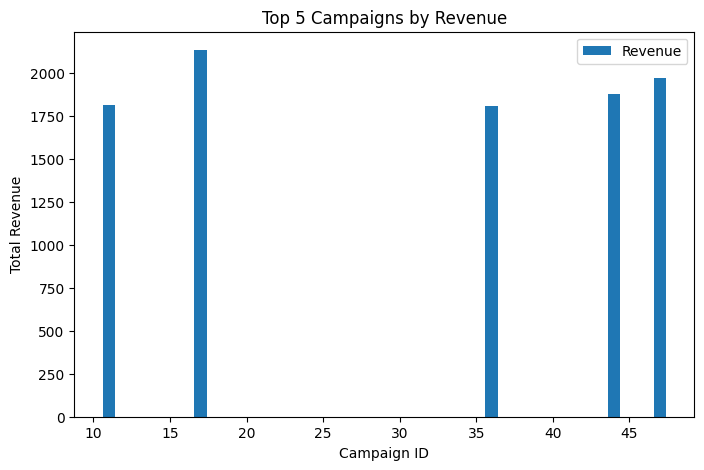

In [70]:
import matplotlib.pyplot as plt


top_campaigns = (
    campaign_metrics
    .sort_values('total_revenue', ascending=False)
    .head(5)
)


plt.figure(figsize=(8,5))
plt.bar(top_campaigns['campaign_id'], top_campaigns['total_revenue'],label="Revenue")

plt.title("Top 5 Campaigns by Revenue")
plt.xlabel("Campaign ID")
plt.ylabel("Total Revenue")
plt.legend()

plt.show()

**Line Chart — Campaign Conversion Trend**

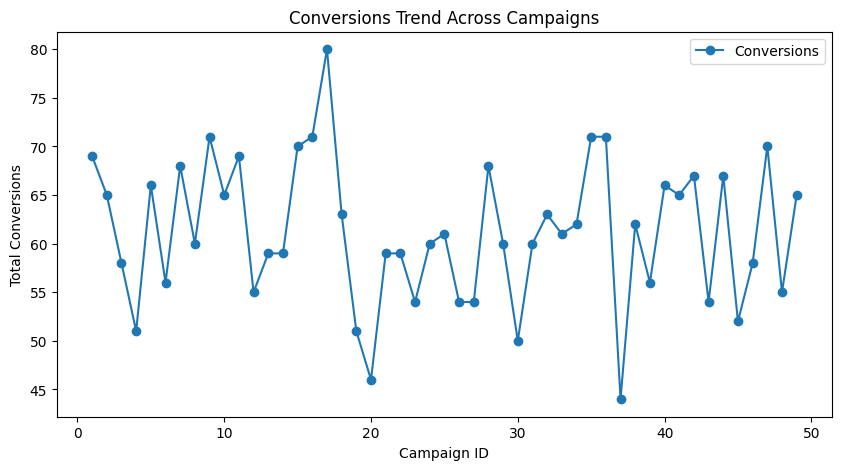

In [71]:
plt.figure(figsize=(10,5))

sorted_campaigns = campaign_metrics.sort_values('campaign_id')

plt.plot(sorted_campaigns['campaign_id'],
         sorted_campaigns['total_conversions'],
         marker='o',
         label="Conversions")

plt.title("Conversions Trend Across Campaigns")
plt.xlabel("Campaign ID")
plt.ylabel("Total Conversions")
plt.legend()
plt.show()

**Heatmap — Device vs Geo Conversion Rate**

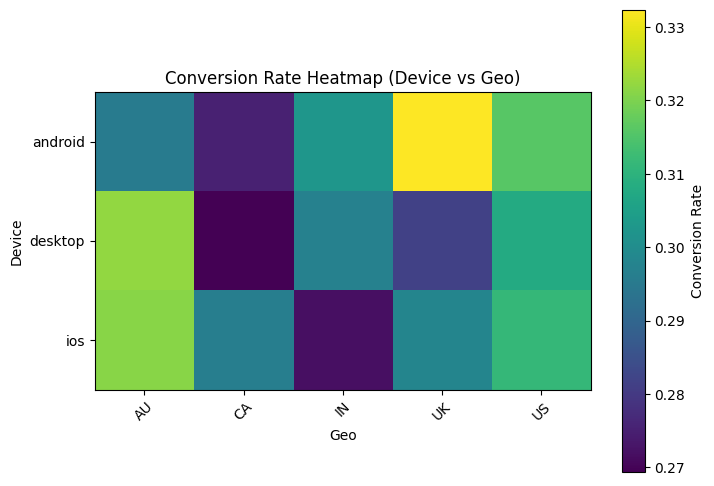

In [73]:
pivot = df.pivot_table(
    values='is_conversion',
    index='device',
    columns='geo',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
plt.imshow(pivot)

plt.title("Conversion Rate Heatmap (Device vs Geo)")
plt.xlabel("Geo")
plt.ylabel("Device")

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.colorbar(label="Conversion Rate")
plt.show()

## Conclusion

This project demonstrates an end-to-end ETL pipeline for processing affiliate marketing data. The pipeline ensures data quality, computes business KPIs, and enables insights into campaign and publisher performance.

The analysis helps identify high-performing campaigns, optimize marketing strategies, and understand user conversion behavior.